In [34]:
import pandas as pd

In [ ]:
df = pd.read_csv('./data/raw_data/merged_data.csv')
df.head(5)

In [ ]:
df_ict = df[df['occupation'] == 'ICT'] 
df_rnd = df[df['occupation'] == 'RND']

In [ ]:
df = pd.concat([df_ict, df_rnd], ignore_index=True)
df = df[['question_raw','answer_raw']]
df.to_csv('./data/data_preprocessing/sorted_data.csv', index=False, encoding='utf-8-sig')

In [35]:
df = pd.read_csv('./data/data_preprocessing/sorted_data.csv')
df.head(5)

,question_raw,answer_raw
0,지원자님 일을 하다 보면 영어로 서류를 작성해야 할 일이 생길 수 있습니다 지원자님...,네 가능합니다. 영어로 서류를 작성해야 할 시에 할 시를 대비하기 위해서 어 많은 ...
1,커뮤니케이션을 잘 할 수 있는 본인만의 스킬이 있나요 있다면 저희에게 한 번 직접 ...,커뮤니케이션을 잘 할 수 있는 저만의 스킬은 소소하게 스물 토크를 통해서 하는 것인...
2,어 지원장님은 의견을 주장해야 될 때 강하게 주장을 하시나요 아니면 약하게 하시나요...,의견을 주장할 때 원래는 강하게 하는 편이었는데 요즘은 강하게 하기 보다는 적당하게...
3,지금까지 살아오시면서 가장 힘들었던 경험에는 어떤 것이 있는지요 그 경험도 말씀해 ...,지금까지 살아오면서 가장 힘들었던 경험은 대학 입시에서 과를 결정하는 데 부모님과 ...
4,면접자분이 역사 속에서 가장 존경하는 일 인물을 말씀해 주시고 그리고 왜 그 인물을...,역사 속에서 가장 존경하는 인물은 성경에 나오는 인물인 모세인데요. 모세는 이스라엘...


In [36]:
# 한글 아닌 데이터 제거
df['question_raw'] = df['question_raw'].replace(r'[^0-9가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', regex=True)
df['answer_raw'] = df['answer_raw'].replace(r'[^0-9가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', regex=True)

In [37]:
from tqdm import tqdm
from konlpy.tag import Okt
# def load_ko_stopwords(filepath):
#     with open(filepath, 'r', encoding='UTF-8') as f:
#         return [line.strip() for line in f]

okt = Okt()

def load_ko_stopwords(filepath):
    with open(filepath, 'r', encoding='UTF-8') as f:
        return [line.strip() for line in f]
    
def get_core_sentence(text):
    sentences = [s.strip() for s in text.split('.') if s.strip()]
    
    if len(sentences) >= 2:
        return sentences[0] + '. ' + sentences[-1] + '.'
    elif len(sentences) == 1:
        return sentences[0] + '.'
    return text

def preprocess(sentences, ko_stopwords, answer=False):
    result = []
    for sentence in tqdm(sentences):
        if answer:
            sentence = get_core_sentence(sentence)
        tokens = okt.morphs(sentence)

        if answer:
            tokens = ['<sos>'] + tokens + ['<eos>']
        else:
            tokens = tokens + ['<eos>']

        tokens = [token for token in tokens if token not in ko_stopwords]
        result.append(tokens)
    return result

ko_stopwords = load_ko_stopwords('./ko_stopwords.txt')
question = preprocess(df['question_raw'], ko_stopwords)
answer = preprocess(df['answer_raw'], ko_stopwords)

100%|██████████| 11926/11926 [07:09<00:00, 27.78it/s]


In [38]:
import torch
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

BATCH_SIZE = 16                # 배치 크기
MAX_VOCAB_SIZE = 8000         # 단어사전 크기
EMBEDDING_DIM = 64            # 임베딩 차원
LATENT_DIM = 128               # 뉴런 수

In [39]:
# 토크나이저, 정수 시퀀스 변환
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<UNK>')
tokenizer.fit_on_texts(question + answer)

question_seq = tokenizer.texts_to_sequences(question)
answer_seq = tokenizer.texts_to_sequences(answer)

In [40]:
# 최대 문장 길이 확인
# num_words = len(tokenizer.word_index) + 1
num_words = MAX_VOCAB_SIZE
q_max_len = max(len(s) for s in question_seq)
a_max_len = max(len(s) for s in answer_seq)

print(f'{num_words = }')
print(f'{q_max_len = }')
print(f'{a_max_len = }')

num_words = 8000
q_max_len = 57
a_max_len = 400


In [41]:
q_len = 40
a_len = 100

# 패딩: 질문이 훨씬 짧으므로 pre로 설정
question_input = pad_sequences(question_seq, maxlen=q_len, padding='pre')
answer_input = pad_sequences(answer_seq, maxlen=a_len, padding='post')

print(question_input.shape)
print(answer_input.shape)

print(question_input[1000])
print([tokenizer.index_word[s] for s in question_input[1000] if s != 0])
print(answer_input[1000])
print([tokenizer.index_word[s] for s in answer_input[1000] if s != 0])

(11926, 40)
(11926, 100)
[   0    0    0    0    0    0    0    0    0  408    6 5593   16  209
  296   33  461    8   78   57    9 1955  461   35  493  600   21   40
   68    2    1 3668    6  109   50   20  138  182  150   13]
['개발자', '가', '갖추어야', '할', '중요한', '역량', '과', '태도', '는', '무엇', '이라고', '생각', '하시고', '태도', '로', '인해서', '긍정', '적', '인', '경험', '을', '<UNK>', '케이스', '가', '있다면', '말씀', '해', '주', '시기', '바랍니다', '<eos>']
[   7    2  264    7   28  200    7    2  457 5791    7   15   56  646
   33 1658    5 5029 2726    7    3  117   38  174   24    4  117    2
   79  993    3   78  130 7827  993    2   64   17   48  993    2 1356
   64   17    3    7    2  912   14    7    3  117   38  174   24    4
  117    2   14  214  129  408   53  209    7   15    1   57    9   26
    3  993    2 1896   64   17    3  912   95    3 1385 1658   10    2
  375    1    1  895   98  169  424   91 3911  117    3 1076  190    9
   26   13]
['것', '을', '없는', '것', '에서', '새로운', '것', '을', '만들어', '낸다는', '것', '은', 

In [42]:
class InterviewDataset(Dataset):
    def __init__(self, question_input, answer_input):
        self.question_input = torch.tensor(question_input, dtype=torch.long)
        self.answer_input = torch.tensor(answer_input, dtype=torch.long)
        
    def __len__(self):
        return len(self.question_input)
    
    def __getitem__(self, idx):
        return self.question_input[idx], self.answer_input[idx]

In [49]:
X_train, X_val, y_train, y_val = train_test_split(question_input, answer_input, test_size=0.2, random_state=42)

train_dataset = InterviewDataset(X_train, y_train)
val_dataset = InterviewDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE)

print('학습 데이터 배치 개수:', len(train_loader))

학습 데이터 배치 개수: 597


In [50]:
# 인코더
class Encoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.gru = nn.GRU(embedding_dim, latent_dim, batch_first=True)

  def forward(self, input_seq):
    input_seq = self.embedding(input_seq)
    outputs, hidden = self.gru(input_seq)
    return hidden

In [51]:
# 디코더
class Decoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.gru = nn.GRU(embedding_dim, latent_dim, batch_first=True)
    self.fc = nn.Linear(latent_dim, vocab_size)

  def forward(self, input_seq, hidden):
    input_seq = self.embedding(input_seq)
    output, hidden = self.gru(input_seq, hidden)
    predict = self.fc(output)
    return predict, hidden

In [52]:
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# seq2seq
class Seq2Seq(nn.Module):
  def __init__(self, encoder, decoder, device):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.device = device

  def forward(self, question, answer, teacher_forcing=0.5):
    batch_size = answer.shape[0]
    target_len = answer.shape[1]
    target_vocab_size = self.decoder.fc.out_features

    outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(self.device)
    hidden = self.encoder(question)

    input_first = answer[:, 0].unsqueeze(1)
    
    for target in range(1, target_len):
      output, hidden = self.decoder(input_first, hidden)
      outputs[:, target, :] = output.squeeze(1)

      teacher_force = random.random() < teacher_forcing
      top = output.argmax(2)

      input_first = answer[:, target].unsqueeze(1) if teacher_force else top

    return outputs

In [53]:
encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder, device).to(device)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8000, 64)
    (gru): GRU(64, 128, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(8000, 64)
    (gru): GRU(64, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=8000, bias=True)
  )
)

In [54]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.01)
epochs = 10

train_losses, train_accs, val_losses, val_accs = [], [], [], [] 

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_tokens = 0, 0, 0

    p_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for q_batch, a_batch in p_bar:
        q_batch, a_batch = q_batch.to(device), a_batch.to(device)
        
        optimizer.zero_grad()
        output = model(q_batch, a_batch) # [batch, seq_len, vocab]
        
        # 1. Loss 계산 (차원 펼치기)
        loss = criterion(output.view(-1, num_words), a_batch.view(-1))
        loss.backward()
        optimizer.step()

        # 2. 통계 업데이트 (중복 방지)
        current_loss = loss.item()
        train_loss += current_loss
        p_bar.set_postfix(loss=f"{current_loss:.4f}")

        # 3. 정확도 계산
        preds = output.argmax(dim=-1)
        mask = a_batch != 0
        train_correct += ((preds == a_batch) & mask).sum().item()
        train_tokens += mask.sum().item()

    # 에포크 종료 후 평균 계산
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_correct / train_tokens

    model.eval()
    val_loss, val_correct, val_tokens = 0, 0, 0
    with torch.no_grad():
        for q_batch, a_batch in val_loader:
            q_batch, a_batch = q_batch.to(device), a_batch.to(device)
            output = model(q_batch, a_batch)
            
            loss = criterion(output.view(-1, num_words), a_batch.view(-1))
            val_loss += loss.item()

            preds = output.argmax(dim=-1)
            mask = a_batch != 0
            val_correct += ((preds == a_batch) & mask).sum().item()
            val_tokens += mask.sum().item()

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_correct / val_tokens
    
    # 기록 저장
    train_losses.append(avg_train_loss)
    train_accs.append(avg_train_acc)
    val_losses.append(avg_val_loss)
    val_accs.append(avg_val_acc)

    print(f'[{epoch+1}/{epochs}] T_Loss: {avg_train_loss:.4f} | T_Acc: {avg_train_acc:.4f} | V_Loss: {avg_val_loss:.4f} | V_Acc: {avg_val_acc:.4f}')

Epoch 1: 100%|██████████| 597/597 [08:22<00:00,  1.19it/s, loss=5.7674]


[1/10] T_Loss: 5.9677 | T_Acc: 0.1186 | V_Loss: 5.6393 | V_Acc: 0.1389


Epoch 2: 100%|██████████| 597/597 [07:53<00:00,  1.26it/s, loss=5.4673]


[2/10] T_Loss: 5.4858 | T_Acc: 0.1456 | V_Loss: 5.4716 | V_Acc: 0.1483


Epoch 3: 100%|██████████| 597/597 [07:51<00:00,  1.27it/s, loss=4.9771]


...

[8/10] T_Loss: 5.0640 | T_Acc: 0.1596 | V_Loss: 5.3932 | V_Acc: 0.1541


Epoch 9: 100%|██████████| 597/597 [07:52<00:00,  1.26it/s, loss=5.2537]


[9/10] T_Loss: 5.0328 | T_Acc: 0.1613 | V_Loss: 5.4094 | V_Acc: 0.1527


Epoch 10: 100%|██████████| 597/597 [07:53<00:00,  1.26it/s, loss=4.9456]


[10/10] T_Loss: 5.0156 | T_Acc: 0.1620 | V_Loss: 5.3817 | V_Acc: 0.1563


In [ ]:
# 모델 저장
torch.save(model, 'interview_model.pth')

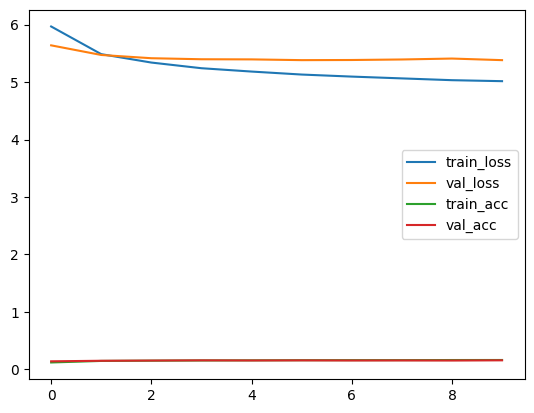

In [56]:
import matplotlib.pyplot as plt

pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs,
}).plot()
plt.show()

In [57]:
model = torch.load('interview_model.pth', weights_only=False)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8000, 64)
    (gru): GRU(64, 128, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(8000, 64)
    (gru): GRU(64, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=8000, bias=True)
  )
)

In [58]:
def predict(question_str, model, tokenizer, max_len=100):
    model.eval()
    with torch.no_grad():
        tokens = okt.morphs(question_str) 
        tokens = tokens + ['<eos>']
        
        seq = tokenizer.texts_to_sequences([tokens])
        input_tensor = torch.tensor(pad_sequences(seq, maxlen=40, padding='pre')).to(device)

        hidden = model.encoder(input_tensor)

        start_token = tokenizer.word_index.get('<sos>', 2) 
        input_step = torch.tensor([[start_token]]).to(device)

        result = []
        for _ in range(max_len):
            output, hidden = model.decoder(input_step, hidden)
            top1 = output.argmax(2) 
            
            idx = top1.item()
            if idx == tokenizer.word_index.get('<eos>', 3) or idx == 0:
                break
                
            word = tokenizer.index_word.get(idx, '<UNK>')
            result.append(word)
            
            input_step = top1 

    return ' '.join(result)

test_question = "본인만의 스트레스 해소법이 있나요?"
ans = predict(test_question, model, tokenizer)

print(f"질문: {test_question}")
print(f"답변: {ans}")

질문: 본인만의 스트레스 해소법이 있나요?
답변: <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> 을 <UNK> <UNK> <UNK> 을 <UNK> <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> <UNK> 을 <UNK> 을 <UNK> 을 <UNK> 을 <UNK>
